# Spatial Analysis of ZüriWieNeu Reports

This notebook analyses spatial and temporal patterns in ZüriWieNeu reports. 
It uses the cleaned reports_quartiere_clean dataset to answer four questions: 
1. Which quartiers have the most reports?
2. Which report categories are most common?
3. Which categories dominate in each quartier?
4. How have report numbers changed over time?

In [1]:
import geopandas as gpd
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

DATA_PROCESSED = Path("../data/processed")
OUTPUTS = Path("../outputs")

In [2]:
reports_quartiere_clean = gpd.read_file(
    DATA_PROCESSED / "reports_quartiere_clean.gpkg"
)

quartiere_join_clean = gpd.read_file(
    DATA_PROCESSED / "quartiere_join.gpkg"
)

In [3]:
print(reports_quartiere_clean.crs)
print(quartiere_join_clean.crs)

EPSG:4326
EPSG:4326


In [4]:
reports_quartiere_clean.head()

,service_request_id,requested_datetime,updated_datetime,service_code,status,title,detail,name,kuerzel,geometry
0,1,2013-03-14 15:16:15,2013-04-12 07:59:30,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,Albisrieden,91,POINT (8.48423 47.37404)
1,2,2013-03-14 15:17:57,2013-04-12 08:00:22,Strasse/Trottoir/Platz,fixed - council,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,Höngg,101,POINT (8.50819 47.39512)
2,4,2013-03-15 09:14:16,2013-04-12 08:08:10,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,Saatlen,121,POINT (8.55959 47.40826)
3,5,2013-03-15 09:17:15,2013-04-12 08:09:05,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,Wipkingen,102,POINT (8.52163 47.39913)
4,6,2013-03-15 10:36:53,2013-04-23 13:50:33,Abfall/Sammelstelle,fixed - council,Arbeitskist,Arbeitskiste ist rund herum verschmiert,City,14,POINT (8.53889 47.37545)


## Reports per Neighbourhood

In [5]:
reports_per_quartier = (
    reports_quartiere_clean
    .groupby("name")
    .size()
    .reset_index(name="report_count")
)
reports_per_quartier.head()

,name,report_count
0,Affoltern,2437
1,Albisrieden,2059
2,Alt-Wiedikon,2532
3,Altstetten,4136
4,City,1754


In [6]:
reports_per_quartier_gdf = reports_per_quartier.merge(
    quartiere_join_clean,
    on = "name",
    how="left"
)

reports_per_quartier_gdf.head()

,name,report_count,kuerzel,geometry
0,Affoltern,2437,111,"POLYGON ((8.48438 47.42904, 8.48443 47.42899, ..."
1,Albisrieden,2059,91,"POLYGON ((8.46419 47.36838, 8.4642 47.36783, 8..."
2,Alt-Wiedikon,2532,31,"POLYGON ((8.50583 47.36922, 8.50583 47.36922, ..."
3,Altstetten,4136,92,"POLYGON ((8.44802 47.38025, 8.44848 47.37966, ..."
4,City,1754,14,"POLYGON ((8.52922 47.3692, 8.52943 47.36903, 8..."


In [7]:
# Convert the merged DataFrame into a GeoDataFrame and define the geometry column and CRS
reports_per_quartier_gdf = gpd.GeoDataFrame(
    reports_per_quartier_gdf,
    geometry="geometry",
    crs=quartiere_join_clean.crs
)

### Barplot Reports per Neighbourhood

The first analysis counts all reports within each quartier. This provides an overview of where reported issues are most frequent.

In [8]:
reports_per_quartier_sorted = reports_per_quartier_gdf.sort_values(
    "report_count",
    ascending=False
)

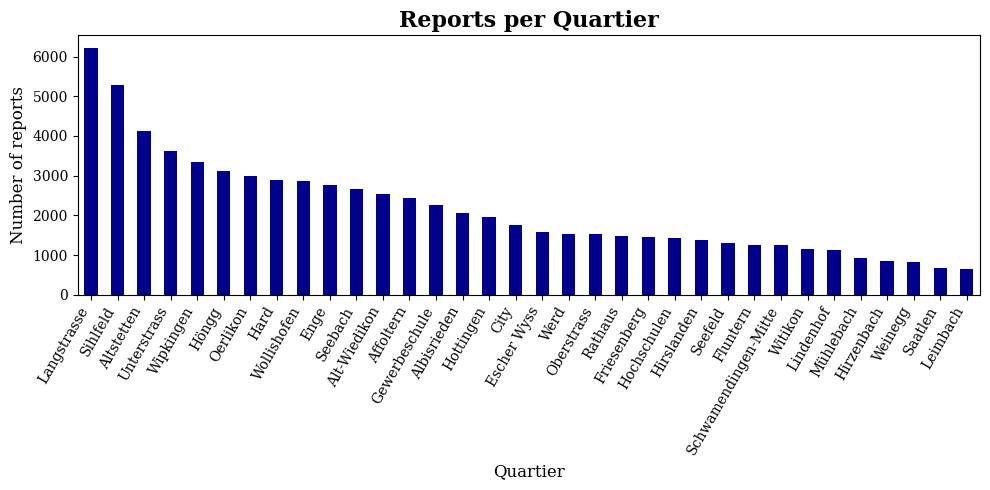

In [9]:
ax = reports_per_quartier_sorted.plot(
    kind="bar",
    x="name",
    y="report_count",
    figsize=(10, 5),
    color="darkblue",
    legend=False
)

ax.set_xlabel("Quartier", fontsize=12, fontfamily="serif")
ax.set_ylabel("Number of reports", fontsize=12, fontfamily="serif")
ax.set_title("Reports per Quartier", fontsize=16, fontweight="bold", fontfamily="serif")
plt.xticks(rotation=60, ha="right", fontfamily="serif")
plt.yticks(fontfamily="serif")
plt.tight_layout()
plt.show()

### Map Reports per Neighbourhood

This choropleth map shows how the number of ZüriWieNeu reports varies across the neighbourhoods of Zurich.

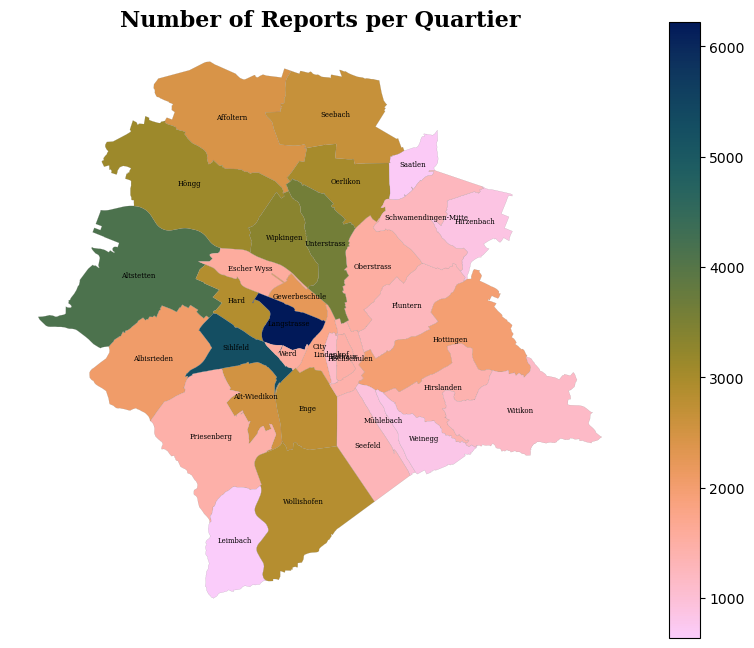

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

reports_per_quartier_gdf.plot(
    ax=ax, 
    column="report_count",
    cmap=cmc.batlow_r,
    legend=True,
    edgecolor="grey",
    linewidth=0.1
)

# Add neighbourhood names at the centroid of each polygon
for idx, row in reports_per_quartier_gdf.iterrows():
    ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["name"],
        fontsize=5,
        ha="center",
        fontfamily="serif"
    )

ax.set_title("Number of Reports per Quartier", fontsize=16, fontweight="bold", fontfamily="serif")
ax.axis("off")
plt.savefig(
    OUTPUTS / "reports_per_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Most Common Report Categories

This counts how often each report category appears in the full dataset. It shows which types of issue categories are most frequently reported across Zurich.

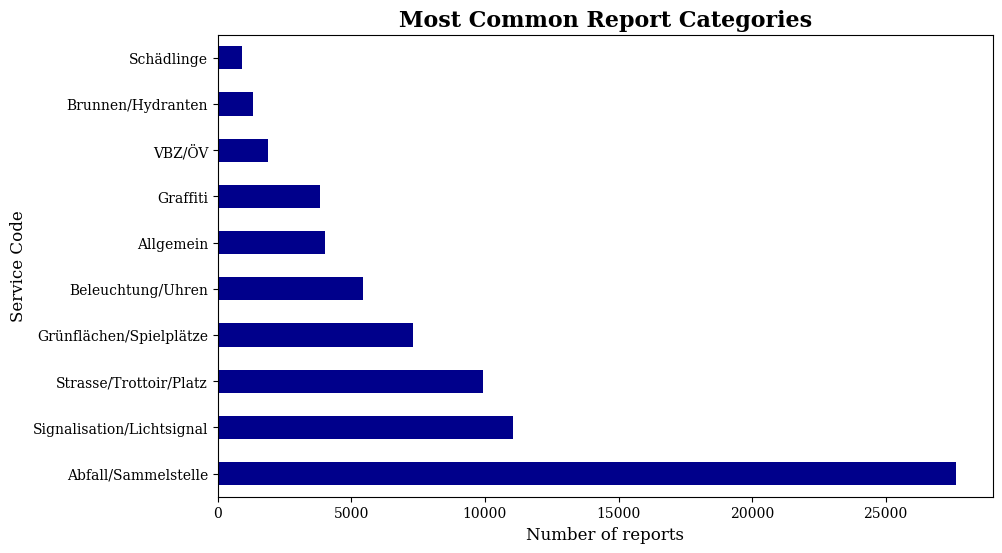

In [11]:
reports_quartiere_clean["service_code"].value_counts().plot(
    kind="barh",
    figsize=(10,6),
    color="darkblue"
)

plt.xlabel("Number of reports", fontsize=12, fontfamily="serif")
plt.ylabel("Service Code", fontsize=12, fontfamily="serif")
plt.title("Most Common Report Categories", fontsize=16, fontweight="bold", fontfamily="serif")
plt.xticks(fontfamily="serif")
plt.yticks(fontfamily="serif")
plt.savefig(
    OUTPUTS / "most_common_report_categories_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Most Common Report Categories per Quartier

For each neighbourhood, the three most frequent report categories are selected. This makes it possible to compare how many reports each quartier has and what kind of problems dominate where.

In [12]:
category_counts = (
    reports_quartiere_clean
    .value_counts(["name", "service_code"])
    .rename("count")
    .reset_index()
)

category_counts.head()

,name,service_code,count
0,Langstrasse,Abfall/Sammelstelle,3880
1,Sihlfeld,Abfall/Sammelstelle,3164
2,Hard,Abfall/Sammelstelle,1641
3,Altstetten,Abfall/Sammelstelle,1414
4,Alt-Wiedikon,Abfall/Sammelstelle,1293


In [13]:
# Keep only the three most frequent categories within each neighbourhood
top_categories = (
    category_counts
    .sort_values(
        ["name", "count"],
        ascending=[True, False]
    )
    .groupby("name")
    .head(3)
)

In [14]:
# Reshape the table so each neighbourhood becomes one row and each report category one column for plotting
category_plot = top_categories.pivot(
    index="name",
    columns="service_code",
    values="count"
).fillna(0)

### Barplot of Dominant Categories by Neighbourhood

This stacked barplot shows the three most frequent report categories in each quartier.

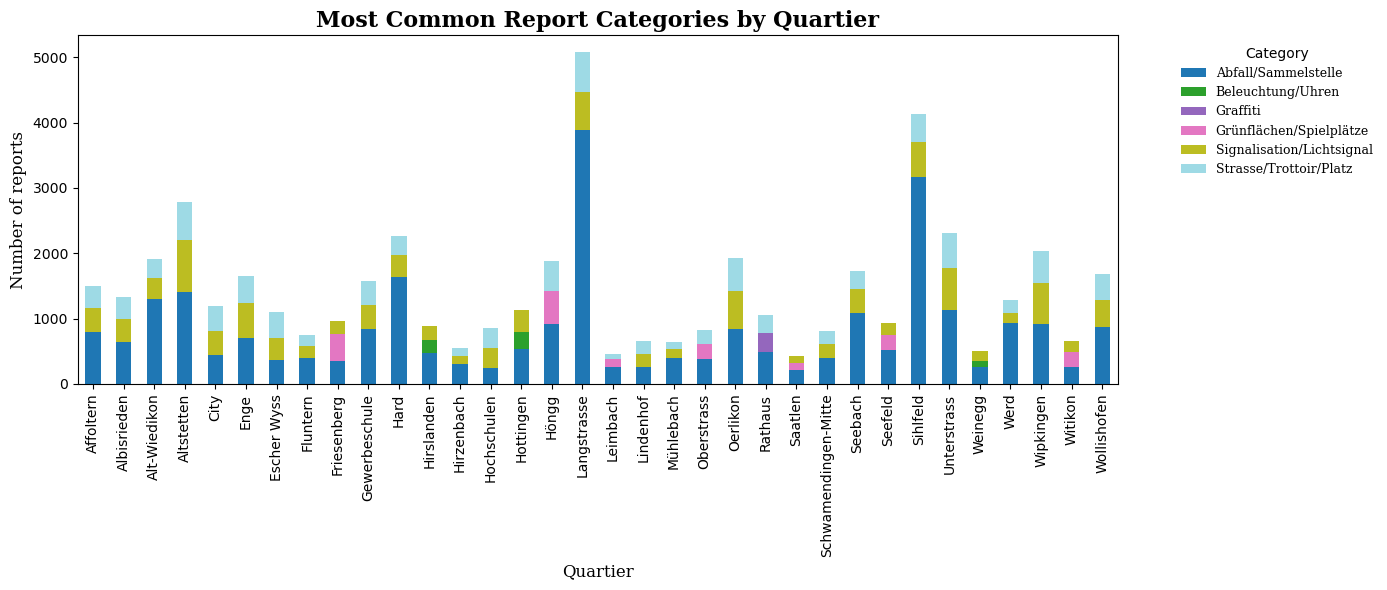

In [15]:
fig, ax = plt.subplots (figsize=(16,7))

category_plot.plot(
    kind = "bar",
    stacked = True,
    figsize= (14,6),
    cmap="tab20",
    ax=ax
)

ax.set_xlabel("Quartier", fontsize=12, fontfamily="serif")
ax.set_ylabel("Number of reports", fontsize=12, fontfamily="serif")
ax.set_title("Most Common Report Categories by Quartier", fontsize=16, fontweight="bold", fontfamily="serif")

ax.legend(
    title = "Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    prop={"family": "serif", "size": 9}
)

plt.tight_layout()
plt.savefig(
    OUTPUTS / "common_report_categories_by_quartier_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [16]:
main_category = (
    category_counts
    .sort_values("count", ascending=False)
    .groupby("name")
    .first()
    .reset_index()
)

In [17]:
# Join the dominant report category of each neighbourhood to the quartier polygon layer
quartiere_main = quartiere_join_clean.merge(
    main_category,
    on="name",
    how="left"
)

### Map of Dominant Category by Neighbourhood

This map shows the most frequent report category in each quartier.

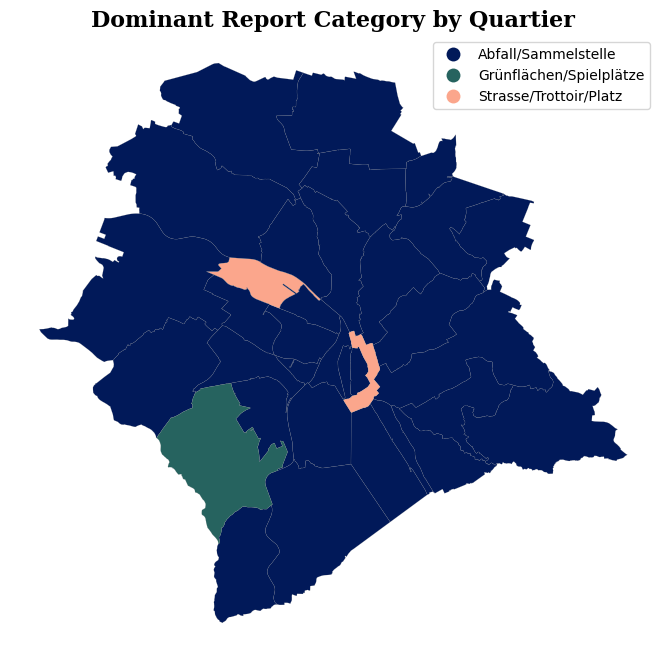

In [18]:
# Map the most frequent report category in each quartier
fig, ax = plt.subplots(figsize=(10, 8))

quartiere_main.plot(
    ax=ax, 
    column="service_code",
    cmap=cmc.batlowS,
    legend=True,
    edgecolor="grey",
    linewidth=0.1
)

ax.set_title("Dominant Report Category by Quartier", fontsize=16, fontweight="bold", fontfamily="serif")
ax.axis("off")
plt.savefig(
    OUTPUTS / "dominant_report_category_by_quartier_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Reports over Time

This time series shows how reporting activity on the ZüriWieNeu platform changed over time by monthly counting all reports.

In [19]:
# Group the reports into monthly intervals and count the number of reports per month
monthly_reports = (
    reports_quartiere_clean
    .set_index("requested_datetime")
    .resample("ME")
    .size()
)

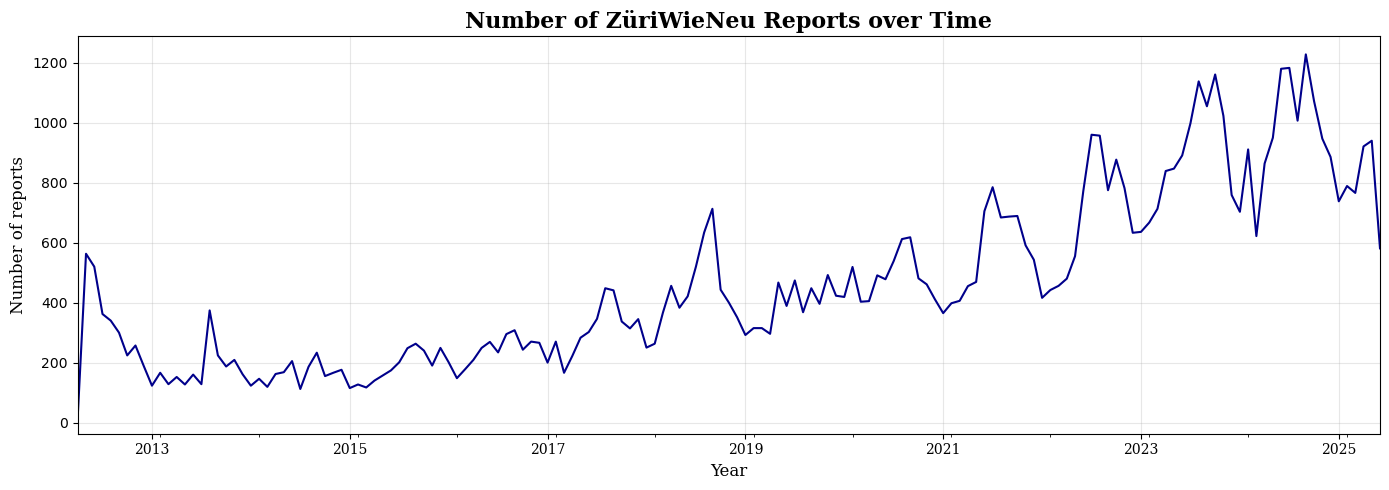

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly_reports.plot(ax=ax, color = "darkblue")

ax.set_xlabel("Year", fontsize=12, fontfamily="serif")
ax.set_ylabel("Number of reports", fontsize=12, fontfamily="serif")
ax.set_title("Number of ZüriWieNeu Reports over Time", fontsize=16, fontweight="bold", fontfamily="serif")

# Show only every second year on the x-axis to improve readability
years = monthly_reports.index[monthly_reports.index.month == 12][::2]
ax.set_xticks(years)
ax.set_xticklabels(years.year, fontfamily="serif")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUTS / "number_of_reports_over_time_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()